# Step 1: Compute  phase space plot

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.integrator.integrate import FastSitnikovSimulation

In [2]:
e = 0.5
sim = FastSitnikovSimulation(e = e)

For this I will need to choose some sample of initial conditions and just plot their trajectories.

Initial conditions: t = 0, v \in (0, escape)
Plot N_it = 50 points, or as many as there are before escape
Plot only points that stay during N_it, to avoid noise from quick escapes.

Note I want roughly equally spaced points for the clarity of the image.

I know in one ray I would miss other islands, so let's do multiple rays. Let me do 6 equally space rays

Now it becomes harder to know if some trajectory clarifies anything

I can add a spacing parameter: Two diff trajectories won't be plotted if they are ever less than spacing apart.

Plot functions will return fig, ax to ensure the user can later easily change title, fontsize and other stuff.


The number of computations is N_it * N_v * N_t. Given that each call to phi takes roughly 2 ms, let's try on the order of  1000s computations.

Let's try to do N_it = 50, N_v = 20, N_t = 6. Should take around 6s, which is fine.

The plot should be a scatter plot with small black dots.

In [5]:
def phase_space_plot(e, N_v, N_t, N_it, random_dist=False, spacing=0):
    # Note spacing makes the code significantly slower.
    if N_v <= 0 or N_t <= 0 or N_it <= 0:
        raise ValueError("N_v, N_t, and N_it must be positive")
    if spacing < 0:
        raise ValueError("spacing must be non-negative")

    sim = FastSitnikovSimulation(e=e)
    period = 2.0 * np.pi
    v_max = 2.0 / np.sqrt(1.0 - e) # This is a very rough estimate. It would be nice to improve it in the future.

    if random_dist:
        rng = np.random.default_rng()
        v_samples = np.sort(rng.uniform(0.0, v_max, size=int(N_v)))
        t_samples = np.sort(rng.uniform(0.0, period, size=int(N_t)))
    else:
        v_samples = np.linspace(0.0, v_max, int(N_v) + 2)[1:-1]
        t_samples = np.linspace(0.0, period, int(N_t), endpoint=False)



    plotted_points = np.empty((0, 2), dtype=float)
    kept_points_t = []
    kept_points_v = []

    for t0 in t_samples:
        for v0 in v_samples:
            trajectory = [(float(v0), float(t0))]
            v_curr = float(v0)
            t_curr = float(t0)

            for _ in range(int(N_it)):
                v_next, t_next = sim.phi_fast(v=v_curr, t=t_curr, return_mod_period=True)
                if v_next is None or t_next is None:
                    break
                trajectory.append((float(v_next), float(t_next)))
                v_curr = float(v_next)
                t_curr = float(t_next)

            if len(trajectory) < int(N_it + 1):
                continue

            trajectory_arr = np.asarray(trajectory, dtype=float)
            if spacing > 0 and plotted_points.size > 0:
                delta_t = np.abs(trajectory_arr[:, None, 1] - plotted_points[None, :, 1])
                delta_t = np.minimum(delta_t, period - delta_t)
                delta_v = trajectory_arr[:, None, 0] - plotted_points[None, :, 0]
                distances = np.sqrt(delta_v * delta_v + delta_t * delta_t)
                if np.any(np.min(distances, axis=1) < spacing):
                    continue

            kept_points_v.extend(trajectory_arr[:, 0])
            kept_points_t.extend(trajectory_arr[:, 1])
            plotted_points = np.vstack((plotted_points, trajectory_arr))

    # Plotting logic here
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": "polar"})
    if kept_points_t:
        ax.scatter(kept_points_t, kept_points_v, s=1, color="black")
    ax.set_rlim(0.0, v_max)
    return fig, ax


Trial and error of what parameters give the most informative good looking plots

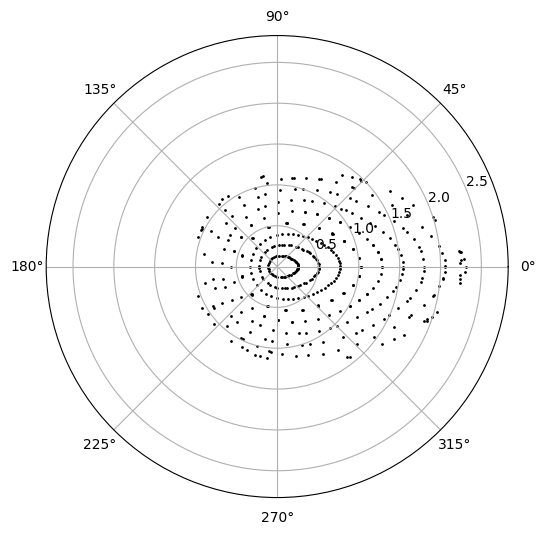

In [ ]:
# Too few trajectories
fig, ax = phase_space_plot(e = 0.5, N_v = 10, N_t = 1, N_it = 50)
plt.show()

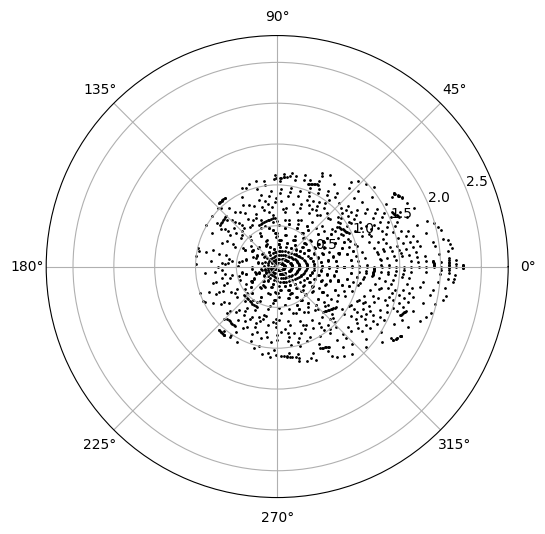

In [ ]:
# Better, thre region with t = np.pi is sparse though
fig, ax = phase_space_plot(e = 0.5, N_v = 30, N_t = 1, N_it = 50)
plt.show()

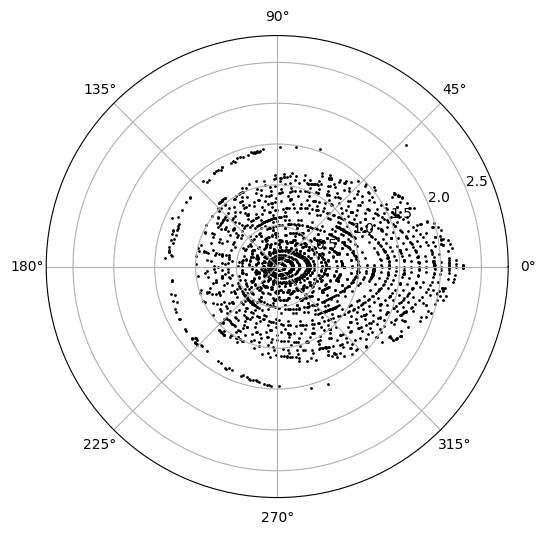

In [ ]:
# Even better, lots of features, you can see a secondary island
fig, ax = phase_space_plot(e = 0.5, N_v = 30, N_t = 3, N_it = 50)
plt.show()

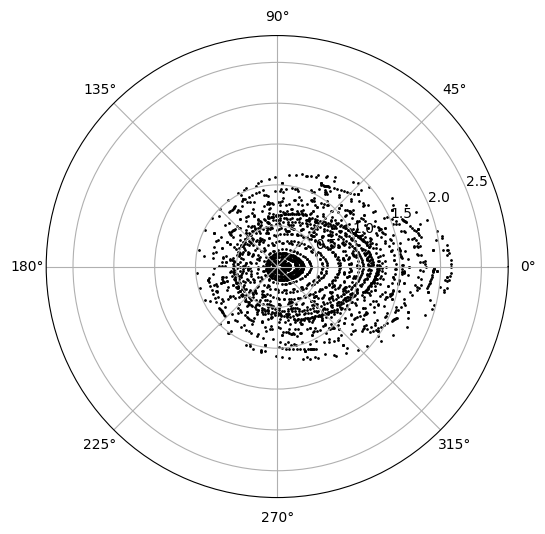

In [21]:
# Even better, lots of features, you can see a secondary island
fig, ax = phase_space_plot(e = 0.5, N_v = 30, N_t = 3, N_it = 50, random_dist=True)
plt.show()

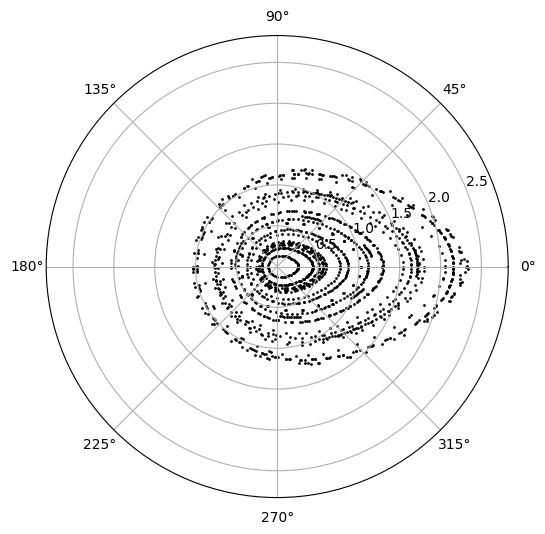

In [16]:
# Compute the plot
fig, ax = phase_space_plot(e = 0.5, N_v = 10, N_t = 6, N_it = 50)
plt.show()